# KMeans sobre features de forma (k=5)

Clustering no supervisado de piezas usando **únicamente variables geométricas dimensionless** (shape features). Se excluyen deliberadamente tamaño, peso y volúmenes.

## Features usados (12 — todos de `03_clean_dataset`)
- `aspect_ratio`, `plane_ratio`, `cyl_ratio`, `complex_ratio` — ratios de caras planas/cilíndricas/complejas
- `material_removal_pct` — % de material removido respecto al stock
- `bbox_ratio_2`, `bbox_ratio_3` — proporciones ordenadas del bounding box (invariantes a tamaño y rotación)
- `face_orientation_distribution.{X+,Y+,Z+}_pct` — distribución de normales de cara
- `direction_count` — # direcciones de mecanizado
- `angled_hole_count_log` — log1p de agujeros angulados

## Flujo
1. Cargar `parts_dedup.parquet`
2. Seleccionar shape features, manejar NaN
3. Estandarizar (StandardScaler)
4. KMeans k=5
5. PCA a 2D para visualizar
6. Caracterización de cada cluster

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

RANDOM_STATE = 42
K = 5

## 1. Cargar dataset dedupado

In [33]:
df = pd.read_parquet('manufacturing_quotes_clean.parquet')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (153, 33)


,radii_id,product_name,partner_country,actual_partner_quoted_price,actual_partner_quoted_quantity,material_title,technology,tolerance_tier,finishing,heat_treatment,axis_recommendation,aspect_ratio,plane_ratio,cyl_ratio,complex_ratio,material_removal_pct,bbox_ratio_2,bbox_ratio_3,face_orientation_distribution.X+_pct,face_orientation_distribution.Y+_pct,face_orientation_distribution.Z+_pct,direction_count,angled_hole_count_log,part_volume_cm3,weight_g,stock_volume_cm3,removed_volume_cm3,metadata.bounding_box_mm.x,metadata.bounding_box_mm.y,metadata.bounding_box_mm.z,total_holes,faces_qty,metadata.max_hole_depth_mm
0,RAD-6058,Finger Separator,Asia,87.000000,2.0,other,3D_Printing_FDM,tight,as_machined,False,3-axis,3.39,0.333,0.667,0.0,89.4,0.296296,0.294673,0.000000,0.000000,1.000000,1.0,0.0,0.60,4.67,5.63,5.04,7.956175,8.0,27.0,1.0,12.0,27.0
1,RAD-6058,Gripper Finger Support,Asia,132.000000,2.0,other,3D_Printing_FDM,tight,as_machined,False,3-axis,3.23,0.480,0.520,0.0,85.6,0.608247,0.309278,0.333333,0.416667,0.250000,3.0,0.0,5.54,43.48,38.41,32.87,48.500000,29.5,15.0,5.0,25.0,5.0
2,RAD-6058,Rocker Base,Asia,4.809518,2.0,other,3D_Printing_FDM,tight,as_machined,False,3-axis,1.52,0.462,0.538,0.0,75.3,0.750000,0.656250,0.083333,0.583333,0.333333,3.0,0.0,0.91,7.16,3.69,2.77,16.000000,10.5,12.0,6.0,52.0,2.6


## 2. Seleccionar shape features y manejar NaN

Solo variables que describen **forma**, no tamaño ni peso. Los NaN vienen de piezas sin geometría completa (bbox inválido o sin caras detectadas); las descartamos para el clustering.

In [34]:
SHAPE_FEATURES = [
    'aspect_ratio', 'plane_ratio', 'cyl_ratio', 'complex_ratio',
    'material_removal_pct',
    'bbox_ratio_2', 'bbox_ratio_3',
    'face_orientation_distribution.X+_pct',
    'face_orientation_distribution.Y+_pct',
    'face_orientation_distribution.Z+_pct',
    'direction_count',
    'angled_hole_count_log',
]

X_df = df[SHAPE_FEATURES].copy()

print(f'Features: {len(SHAPE_FEATURES)}')
print(f'\nNaN por columna:')
print(X_df.isna().sum().to_string())

# Drop filas con NaN en cualquier shape feature
mask = X_df.notna().all(axis=1)
X_df = X_df[mask].reset_index(drop=True)
df_clean = df[mask].reset_index(drop=True)

print(f'\nFilas post-dropna: {len(X_df)} (de {len(df)})')

Features: 12

NaN por columna:
aspect_ratio                            0
plane_ratio                             0
cyl_ratio                               0
complex_ratio                           0
material_removal_pct                    0
bbox_ratio_2                            3
bbox_ratio_3                            3
face_orientation_distribution.X+_pct    3
face_orientation_distribution.Y+_pct    3
face_orientation_distribution.Z+_pct    3
direction_count                         3
angled_hole_count_log                   3

Filas post-dropna: 150 (de 153)


## 3. Estandarizar

KMeans usa distancia euclidiana → features deben estar en la misma escala.

In [35]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_df.values)

print(f'X_scaled shape: {X_scaled.shape}')
print(f'mean por feature (debería ser ~0): {np.round(X_scaled.mean(axis=0), 3)}')
print(f'std  por feature (debería ser ~1): {np.round(X_scaled.std(axis=0), 3)}')

X_scaled shape: (150, 12)
mean por feature (debería ser ~0): [ 0. -0.  0.  0. -0. -0.  0. -0.  0.  0. -0.  0.]
std  por feature (debería ser ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 4. KMeans con k=5

In [36]:
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=20)
labels = kmeans.fit_predict(X_scaled)

df_clean['cluster'] = labels

print(f'Inercia: {kmeans.inertia_:.2f}')
print(f'\nTamaño de cada cluster:')
print(pd.Series(labels).value_counts().sort_index().to_string())

Inercia: 1048.37

Tamaño de cada cluster:
0    39
1    39
2    36
3     8
4    28


## 5. PCA a 2D para visualizar

In [37]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f'Varianza explicada: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}')
print(f'Acumulada:          {pca.explained_variance_ratio_.sum():.1%}')

# También proyectamos los centroides al espacio PCA
centroids_pca = pca.transform(kmeans.cluster_centers_)

Varianza explicada: PC1=22.4%, PC2=19.4%
Acumulada:          41.8%


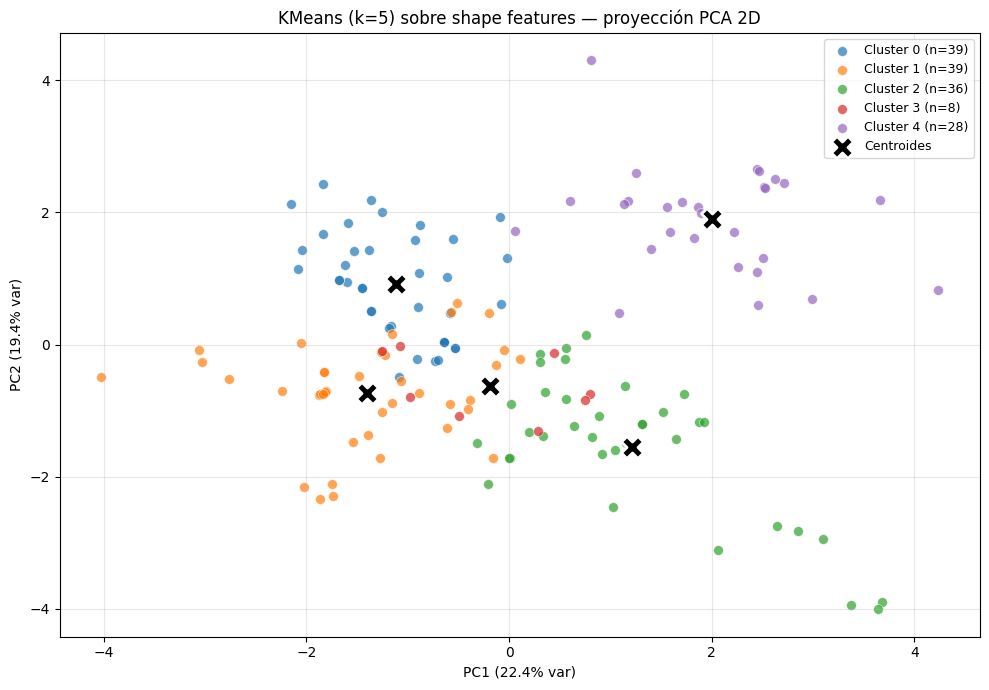

In [38]:
fig, ax = plt.subplots(figsize=(10, 7))

cmap = plt.get_cmap('tab10')
for k in range(K):
    m = labels == k
    ax.scatter(X_pca[m, 0], X_pca[m, 1], s=50, alpha=0.7, color=cmap(k), label=f'Cluster {k} (n={m.sum()})', edgecolor='white', linewidth=0.5)

# Centroides
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='X', s=250, c='black', edgecolor='white', linewidth=2, label='Centroides', zorder=10)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
ax.set_title(f'KMeans (k={K}) sobre shape features — proyección PCA 2D')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Interpretación: ¿qué describe cada cluster?

Mostramos la **media de cada shape feature por cluster** (en unidades originales, no estandarizadas) para entender la geometría dominante de cada grupo.

In [39]:
cluster_means = X_df.copy()
cluster_means['cluster'] = labels
summary = cluster_means.groupby('cluster').mean().round(3)
summary['n'] = pd.Series(labels).value_counts().sort_index()
summary = summary[['n'] + SHAPE_FEATURES]
summary

,n,aspect_ratio,plane_ratio,cyl_ratio,complex_ratio,material_removal_pct,bbox_ratio_2,bbox_ratio_3,face_orientation_distribution.X+_pct,face_orientation_distribution.Y+_pct,face_orientation_distribution.Z+_pct,direction_count,angled_hole_count_log
cluster,,,,,,,,,,,,,
0,39,7.801,0.309,0.575,0.008,41.741,0.493,0.152,0.318,0.213,0.469,2.974,0.285
1,39,6.290,0.509,0.314,0.066,68.021,0.418,0.204,0.320,0.326,0.354,2.769,0.000
2,36,2.508,0.263,0.471,0.126,80.378,0.786,0.543,0.265,0.492,0.243,2.583,0.831
3,8,3.345,0.246,0.469,0.037,71.562,0.580,0.366,0.964,0.000,0.036,1.125,0.000
4,28,5.365,0.151,0.531,0.042,71.536,0.861,0.348,0.033,0.045,0.922,1.286,0.332


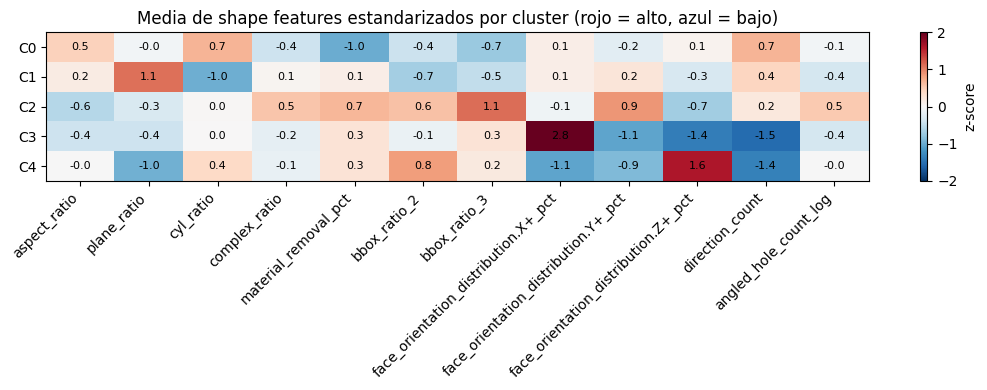

In [40]:
# Heatmap de features estandarizados por cluster (más fácil ver desviaciones)
cluster_means_scaled = pd.DataFrame(X_scaled, columns=SHAPE_FEATURES)
cluster_means_scaled['cluster'] = labels
heat = cluster_means_scaled.groupby('cluster').mean()

fig, ax = plt.subplots(figsize=(11, 4))
im = ax.imshow(heat.values, cmap='RdBu_r', vmin=-2, vmax=2, aspect='auto')
ax.set_xticks(range(len(SHAPE_FEATURES)))
ax.set_xticklabels(SHAPE_FEATURES, rotation=45, ha='right')
ax.set_yticks(range(K))
ax.set_yticklabels([f'C{i}' for i in range(K)])
ax.set_title('Media de shape features estandarizados por cluster (rojo = alto, azul = bajo)')
plt.colorbar(im, ax=ax, label='z-score')

# Anotar valores
for i in range(K):
    for j in range(len(SHAPE_FEATURES)):
        ax.text(j, i, f'{heat.values[i, j]:.1f}', ha='center', va='center', fontsize=8, color='black')

plt.tight_layout()
plt.show()

## 7. Guardar etiquetas

Guardamos `parts_dedup` con la columna `cluster` adicional para reutilizar en análisis posteriores.

In [41]:
df_clean.to_parquet('parts_clustered.parquet', index=False)
df_clean.to_csv('parts_clustered.csv', index=False)
print(f'Guardado: parts_clustered.parquet + .csv ({df_clean.shape})')

Guardado: parts_clustered.parquet + .csv ((150, 34))
